# QFM-Conditioned Pixel Diffusion on Quark/Gluon Jet Images (QG)

This notebook ports the **QFM-conditioned diffusion** idea from `hybrid_dm.ipynb` to the **QG jet dataset**.

## Core idea
- We keep the **diffusion process in pixel space** (stable sampling, no fragile decode).
- We feed a **quantum / quantum-inspired feature map** as **conditioning** to the denoiser.

In this repo, we already have a patch-based quantum encoding for QG stored as `..._encoded.pt` (4 channels on a 32×32 grid for 64×64 images). We upsample those features and concatenate them to the noisy image input.

This is the most QG-ready hybrid path because it does **not** rely on MNIST-style masking or analytic decoding.


In [15]:
%cd /Users/masha/Documents/GSOC/GSoC-Quantum-Diffusion-Model

import math
import numpy as np
import h5py
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import pennylane as qml
from sklearn.model_selection import train_test_split
from skimage.metrics import structural_similarity as ssim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)



/Users/masha/Documents/GSOC/GSoC-Quantum-Diffusion-Model
Device: cpu


## 1. Load QG data (same style as other notebooks)
We mirror the preprocessing pattern used in `notebooks/classical/fm_hep.ipynb`.
If you want to exactly match a previously saved encoding, set `preprocess=False`.


In [16]:
QG_channel = 1
num_samples = 1000
filename = f'data/QG{QG_channel}_64x64_1k'

data_X = np.array(h5py.File(filename, 'r')['X'])[:num_samples]
print('Raw data shape:', data_X.shape)

# Aggressive but stable default: work in intensity space [0, 1] (no [-1,1] remap)
preprocess = True
center_data = True

if preprocess:
    data_X = data_X.astype(np.float32)
    data_X = np.log1p(data_X)
    data_X = data_X / (data_X.max() + 1e-8)

x_px = torch.tensor(data_X, dtype=torch.float32).unsqueeze(1)  # (N,1,64,64) in [0,1]

@torch.no_grad()
def center_by_energy_centroid_zeropad(x01):
    # x01: (N,1,H,W) in [0,1]
    N, _, H, W = x01.shape
    w = x01
    w_sum = w.sum(dim=(2,3), keepdim=True) + 1e-8

    yy = torch.arange(H, device=x01.device).view(1, 1, H, 1).float()
    xx = torch.arange(W, device=x01.device).view(1, 1, 1, W).float()

    cy = (w * yy).sum(dim=(2,3), keepdim=True) / w_sum
    cx = (w * xx).sum(dim=(2,3), keepdim=True) / w_sum

    ty = torch.round((H // 2) - cy.squeeze(-1).squeeze(-1).squeeze(1)).to(torch.int64)
    tx = torch.round((W // 2) - cx.squeeze(-1).squeeze(-1).squeeze(1)).to(torch.int64)

    out = torch.zeros_like(x01)

    for i in range(N):
        dy = int(ty[i].item())
        dx = int(tx[i].item())
        src_y0 = max(0, -dy)
        dst_y0 = max(0, dy)
        h = H - max(0, dy) - max(0, -dy)
        src_x0 = max(0, -dx)
        dst_x0 = max(0, dx)
        w_ = W - max(0, dx) - max(0, -dx)
        if h > 0 and w_ > 0:
            out[i, :, dst_y0:dst_y0+h, dst_x0:dst_x0+w_] = x01[i, :, src_y0:src_y0+h, src_x0:src_x0+w_]

    return out

if center_data:
    x_px = center_by_energy_centroid_zeropad(x_px)

print('Pixel tensor:', x_px.shape, 'range:', float(x_px.min()), float(x_px.max()))



Raw data shape: (1000, 64, 64)
Pixel tensor: torch.Size([1000, 1, 64, 64]) range: 0.0 1.0


### Quick visualization


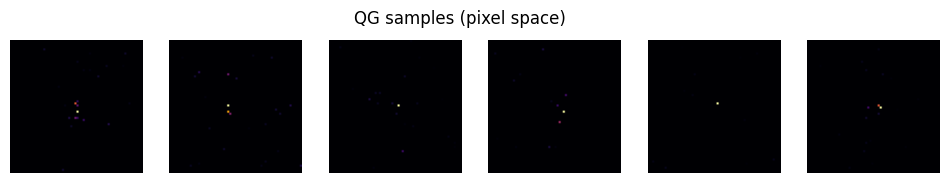

In [17]:
def show_imgs(x, n=6, title=''):
    x = x[:n].detach().cpu().numpy()
    fig, axes = plt.subplots(1, n, figsize=(n*2, 2))
    for i in range(n):
        axes[i].imshow(x[i,0], cmap='inferno')
        axes[i].axis('off')
    if title:
        fig.suptitle(title)
    plt.show()

show_imgs(x_px, title='QG samples (pixel space)')


## 2. Load quantum/encoded conditioning features
We load the stored patch-encoding used by `64fully_quantum.ipynb`:
- shape typically `(N, 32, 32, 4)`
We convert to channels-first and upsample to 64×64 for conditioning.


In [18]:
# QFM / quantum encoding for conditioning
# Option A (recommended for alignment): generate q_enc directly from the same pixel tensor you train on.
# Option B (fast): load precomputed encodings from disk.

generate_q_enc = True
qenc_source = 'pixel'  # 'pixel' (uses x_px) or 'raw' (uses data_X before preprocessing)
use_entangled_patch = True

# Small 2x2-patch circuit -> 4 features (one per qubit)
dev_qenc = qml.device('default.qubit', wires=4)

@qml.qnode(dev_qenc)
def patch_circuit(phi):
    # phi: length-4 array
    for j in range(4):
        qml.RX(np.pi * float(phi[j]), wires=j)

    if use_entangled_patch:
        qml.CNOT(wires=[0, 1])
        qml.CNOT(wires=[2, 3])
        qml.CNOT(wires=[1, 2])

    return [qml.expval(qml.PauliZ(j)) for j in range(4)]

def angle_encode_batch(x_np):
    # x_np: (N, 64, 64)
    N, H, W = x_np.shape
    out = np.zeros((N, H // 2, W // 2, 4), dtype=np.float32)

    for n in range(N):
        for i in range(0, H, 2):
            for j in range(0, W, 2):
                phi = [
                    x_np[n, i, j],
                    x_np[n, i, j + 1],
                    x_np[n, i + 1, j],
                    x_np[n, i + 1, j + 1],
                ]
                out[n, i // 2, j // 2, :] = patch_circuit(phi)
        if (n + 1) % 50 == 0:
            print(f'Encoded {n+1}/{N}', end='')

    return out

if generate_q_enc:
    if qenc_source == 'pixel':
        x_for_qenc = x_px.squeeze(1).detach().cpu().numpy()
    elif qenc_source == 'raw':
        x_for_qenc = data_X.copy()
    else:
        raise ValueError("qenc_source must be 'pixel' or 'raw'")

    q_enc_np = angle_encode_batch(x_for_qenc)
    q_enc = torch.tensor(q_enc_np, dtype=torch.float32)
else:
    enc_path = f'data/QG{QG_channel}_64x64_{num_samples}_encoded.pt'
    q_enc = torch.load(enc_path, map_location='cpu')

print('Encoded shape (NHWC):', q_enc.shape)

# Convert to (N, C, H, W)
if q_enc.ndim == 4 and q_enc.shape[-1] == 4:
    q_enc = q_enc.permute(0, 3, 1, 2).contiguous()

print('Encoded (N,C,H,W):', q_enc.shape)

def upsample_cond(q):
    # q: (N,C,32,32) -> (N,C,64,64)
    return F.interpolate(q, size=(64, 64), mode='bilinear', align_corners=False)

Encoded 50/1000Encoded 100/1000Encoded 150/1000Encoded 200/1000Encoded 250/1000Encoded 300/1000Encoded 350/1000Encoded 400/1000Encoded 450/1000Encoded 500/1000Encoded 550/1000Encoded 600/1000Encoded 650/1000Encoded 700/1000Encoded 750/1000Encoded 800/1000Encoded 850/1000Encoded 900/1000Encoded 950/1000Encoded 1000/1000Encoded shape (NHWC): torch.Size([1000, 32, 32, 4])
Encoded (N,C,H,W): torch.Size([1000, 4, 32, 32])


## 3. Train/Val split + loaders


In [19]:
train_px, val_px, train_q, val_q = train_test_split(x_px, q_enc, test_size=0.2, random_state=42, shuffle=True)
train_loader = DataLoader(TensorDataset(train_px, train_q), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(val_px, val_q), batch_size=64, shuffle=False)
print('Train:', train_px.shape, train_q.shape)

Train: torch.Size([800, 1, 64, 64]) torch.Size([800, 4, 32, 32])


## 4. Diffusion utilities (DDPM-style, epsilon prediction)


In [20]:
def cosine_beta_schedule(timesteps, s=0.008):
    # Nichol & Dhariwal cosine schedule
    steps = timesteps + 1
    x = torch.linspace(0, timesteps, steps) / timesteps
    alphas_cumprod = torch.cos((x + s) / (1 + s) * math.pi / 2) ** 2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return torch.clamp(betas, 1e-6, 0.999)

T = 200
betas = cosine_beta_schedule(T).to(device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)
alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)

sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)
sqrt_recip_alphas = torch.sqrt(1.0 / alphas)
posterior_variance = betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)

def extract(a, t, x_shape):
    out = a.gather(-1, t).float()
    return out.view(-1, 1, 1, 1)

def q_sample(x0, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x0)
    sqrt_ac = extract(sqrt_alphas_cumprod, t, x0.shape)
    sqrt_om = extract(sqrt_one_minus_alphas_cumprod, t, x0.shape)
    return sqrt_ac * x0 + sqrt_om * noise

def predict_x0_from_noise(x_t, t, eps):
    sqrt_ac = extract(sqrt_alphas_cumprod, t, x_t.shape)
    sqrt_om = extract(sqrt_one_minus_alphas_cumprod, t, x_t.shape)
    return (x_t - sqrt_om * eps) / sqrt_ac

def predict_eps_from_x0(x_t, t, x0):
    sqrt_ac = extract(sqrt_alphas_cumprod, t, x_t.shape)
    sqrt_om = extract(sqrt_one_minus_alphas_cumprod, t, x_t.shape)
    return (x_t - sqrt_ac * x0) / sqrt_om



## 5. Models
We train:
- a **pixel baseline** denoiser `p(eps | x_t, t)`
- a **QFM-conditioned** denoiser `p(eps | x_t, qfm(x0), t)`

Both are small time-conditional U-Nets.


In [21]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, padding_mode='reflect'),
            nn.GroupNorm(8, out_ch),
            nn.SiLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, padding_mode='reflect'),
            nn.GroupNorm(8, out_ch),
            nn.SiLU(),
        )
    def forward(self, x):
        return self.net(x)

class Down(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()
        self.conv = DoubleConv(in_ch, out_ch)
        self.time_proj = nn.Linear(time_dim, out_ch)
        self.pool = nn.MaxPool2d(2)
    def forward(self, x, t_emb):
        h = self.conv(x)
        h = h + self.time_proj(t_emb)[:, :, None, None]
        return h, self.pool(h)

class Up(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, 2, stride=2)
        self.conv = DoubleConv(out_ch * 2, out_ch)
        self.time_proj = nn.Linear(time_dim, out_ch)
    def forward(self, x, skip, t_emb):
        x = self.up(x)
        x = torch.cat([x, skip], dim=1)
        x = self.conv(x)
        x = x + self.time_proj(t_emb)[:, :, None, None]
        return x

class TimeEmbedding(nn.Module):
    def __init__(self, n_steps, time_dim):
        super().__init__()
        self.embedding = nn.Embedding(n_steps, time_dim)
        self.mlp = nn.Sequential(nn.Linear(time_dim, time_dim), nn.SiLU())
    def forward(self, t):
        return self.mlp(self.embedding(t))

class SimpleUNet(nn.Module):
    def __init__(self, in_channels, out_channels, base=64, time_dim=128, n_steps=200):
        super().__init__()
        self.time_emb = TimeEmbedding(n_steps, time_dim)
        self.down1 = Down(in_channels, base, time_dim)
        self.down2 = Down(base, base * 2, time_dim)
        self.bot = DoubleConv(base * 2, base * 4)
        self.up2 = Up(base * 4, base * 2, time_dim)
        self.up1 = Up(base * 2, base, time_dim)
        self.out = nn.Conv2d(base, out_channels, 1)
    def forward(self, x, t):
        t_emb = self.time_emb(t)
        h1, x = self.down1(x, t_emb)
        h2, x = self.down2(x, t_emb)
        x = self.bot(x)
        x = self.up2(x, h2, t_emb)
        x = self.up1(x, h1, t_emb)
        return self.out(x)



## 6. Train baseline + conditioned models


In [22]:
# Reproducibility
seed = 123
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Aggressive training objective for sparse jets:
# - predict x0 directly (instead of eps)
# - add sparsity-aware auxiliary losses (top-k pixels, active fraction, energy, radial profile)

use_sparsity_losses = True

# Sparsity knobs
k_top = 64
w_topk = 5.0

thr_active = 0.08
temp_active = 0.02
w_active = 2.0

w_energy = 1.0

radial_bins = 32
w_radial = 1.0

# Precompute radial bin weights for 64x64
H = W = 64
_yy, _xx = torch.meshgrid(torch.arange(H), torch.arange(W), indexing='ij')
_rr = torch.sqrt((_yy - H // 2) ** 2 + (_xx - W // 2) ** 2).float()
_rmax = float(_rr.max())
_edges = torch.linspace(0.0, _rmax + 1e-6, radial_bins + 1)

_bin_w = []
for b in range(radial_bins):
    m = ((_rr >= _edges[b]) & (_rr < _edges[b + 1])).float()
    _bin_w.append(m)

bin_w = torch.stack(_bin_w, dim=0).to(device)         # (B,H,W)
bin_w_flat = bin_w.view(radial_bins, -1)              # (B,P)
bin_norm = bin_w_flat.sum(dim=1).clamp_min(1.0)       # (B,)

@torch.no_grad()
def radial_profile01(x01):
    # x01: (N,1,H,W) -> (N,B)
    x_flat = x01.view(x01.shape[0], -1)
    prof = (x_flat @ bin_w_flat.T) / bin_norm
    return prof

@torch.no_grad()
def topk_mask01(x01, k):
    N = x01.shape[0]
    flat = x01.view(N, -1)
    k = min(k, flat.shape[1])
    _, idx = torch.topk(flat, k, dim=1)
    mask = torch.zeros_like(flat)
    mask.scatter_(1, idx, 1.0)
    return mask.view_as(x01)

model_px = SimpleUNet(in_channels=1, out_channels=1, base=64, time_dim=128, n_steps=T).to(device)
model_px_qfm = SimpleUNet(in_channels=1 + q_enc.shape[1], out_channels=1, base=64, time_dim=128, n_steps=T).to(device)

opt_px = torch.optim.Adam(model_px.parameters(), lr=2e-4)
opt_q = torch.optim.Adam(model_px_qfm.parameters(), lr=2e-4)

# Fixed validation batch + fixed noise/timestep for apples-to-apples comparison across epochs
val_batch_fixed = val_px[:64].to(device)
val_cond_fixed = upsample_cond(val_q[:64].to(device))

eval_gen = torch.Generator(device=device).manual_seed(seed + 1)

def eval_x0_loss_fixed(model, x0, cond=None, t_val=None):
    model.eval()
    with torch.no_grad():
        if t_val is None:
            t_val = torch.full((x0.shape[0],), T // 2, device=device, dtype=torch.long)
        eps = torch.randn(x0.shape, device=device, generator=eval_gen)
        x_t = q_sample(x0, t_val, eps)
        if cond is None:
            x0_hat = model(x_t, t_val)
        else:
            x0_hat = model(torch.cat([x_t, cond], dim=1), t_val)
        x0_hat = torch.clamp(x0_hat, 0.0, 1.0)
        return float(F.mse_loss(x0_hat, x0).item())

def aux_losses_x0(x0_hat, x0_true):
    # All tensors in [0,1]
    mask = topk_mask01(x0_true, k_top)

    mse = (x0_hat - x0_true) ** 2
    topk_loss = (mse * mask).sum() / (mask.sum() + 1e-8)

    E_true = x0_true.sum(dim=(2,3))
    E_pred = x0_hat.sum(dim=(2,3))
    energy_loss = F.mse_loss(E_pred, E_true)

    prof_true = radial_profile01(x0_true)
    prof_pred = radial_profile01(x0_hat)
    radial_loss = F.mse_loss(prof_pred, prof_true)

    frac_true = torch.sigmoid((x0_true - thr_active) / temp_active).mean(dim=(2,3))
    frac_pred = torch.sigmoid((x0_hat - thr_active) / temp_active).mean(dim=(2,3))
    active_loss = F.mse_loss(frac_pred, frac_true)

    return topk_loss, energy_loss, radial_loss, active_loss

def train_epoch_px(model, opt, loader):
    model.train()
    totals, base_losses = [], []

    for x0, _q in loader:
        x0 = x0.to(device)
        t = torch.randint(0, T, (x0.shape[0],), device=device)
        eps = torch.randn_like(x0)
        x_t = q_sample(x0, t, eps)

        x0_hat = model(x_t, t)
        x0_hat = torch.clamp(x0_hat, 0.0, 1.0)

        loss_base = F.mse_loss(x0_hat, x0)
        loss = loss_base

        if use_sparsity_losses:
            l_topk, l_energy, l_radial, l_active = aux_losses_x0(x0_hat, x0)
            loss = loss + w_topk * l_topk + w_energy * l_energy + w_radial * l_radial + w_active * l_active

        opt.zero_grad()
        loss.backward()
        opt.step()

        totals.append(loss.item())
        base_losses.append(loss_base.item())

    return float(np.mean(totals)), float(np.mean(base_losses))

def train_epoch_qfm(model, opt, loader):
    model.train()
    totals, base_losses = [], []

    for x0, q0 in loader:
        x0 = x0.to(device)
        q0 = upsample_cond(q0.to(device))
        t = torch.randint(0, T, (x0.shape[0],), device=device)
        eps = torch.randn_like(x0)
        x_t = q_sample(x0, t, eps)

        x0_hat = model(torch.cat([x_t, q0], dim=1), t)
        x0_hat = torch.clamp(x0_hat, 0.0, 1.0)

        loss_base = F.mse_loss(x0_hat, x0)
        loss = loss_base

        if use_sparsity_losses:
            l_topk, l_energy, l_radial, l_active = aux_losses_x0(x0_hat, x0)
            loss = loss + w_topk * l_topk + w_energy * l_energy + w_radial * l_radial + w_active * l_active

        opt.zero_grad()
        loss.backward()
        opt.step()

        totals.append(loss.item())
        base_losses.append(loss_base.item())

    return float(np.mean(totals)), float(np.mean(base_losses))

# Train longer and log losses
epochs = 20
train_total_px, train_total_q = [], []
train_base_px, train_base_q = [], []
val_base_px, val_base_q = [], []

for e in range(1, epochs + 1):
    ltot_px, lbase_px = train_epoch_px(model_px, opt_px, train_loader)
    ltot_q, lbase_q = train_epoch_qfm(model_px_qfm, opt_q, train_loader)

    v_px = eval_x0_loss_fixed(model_px, val_batch_fixed)
    v_q = eval_x0_loss_fixed(model_px_qfm, val_batch_fixed, cond=val_cond_fixed)

    train_total_px.append(ltot_px)
    train_total_q.append(ltot_q)
    train_base_px.append(lbase_px)
    train_base_q.append(lbase_q)
    val_base_px.append(v_px)
    val_base_q.append(v_q)

    if e == 1 or e % 5 == 0:
        print(
            f"Epoch {e:3d}/{epochs} | "
            f"train_total: px={ltot_px:.4f} q={ltot_q:.4f} | "
            f"train_x0: px={lbase_px:.4f} q={lbase_q:.4f} | "
            f"val_x0(fixed): px={v_px:.4f} q={v_q:.4f}"
        )



Epoch   1/20 | train_total: px=77194.1258 q=103550.5049 | train_x0: px=0.0082 q=0.0086 | val_x0(fixed): px=0.0000 q=0.0000
Epoch   5/20 | train_total: px=0.0877 q=0.0879 | train_x0: px=0.0000 q=0.0000 | val_x0(fixed): px=0.0000 q=0.0000
Epoch  10/20 | train_total: px=0.0894 q=0.0880 | train_x0: px=0.0000 q=0.0000 | val_x0(fixed): px=0.0000 q=0.0000
Epoch  15/20 | train_total: px=0.0882 q=0.0877 | train_x0: px=0.0000 q=0.0000 | val_x0(fixed): px=0.0000 q=0.0000
Epoch  20/20 | train_total: px=0.0880 q=0.0875 | train_x0: px=0.0000 q=0.0000 | val_x0(fixed): px=0.0000 q=0.0000


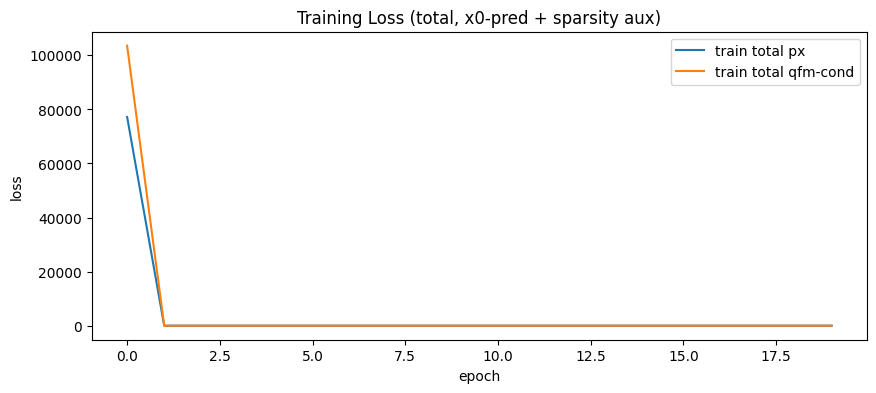

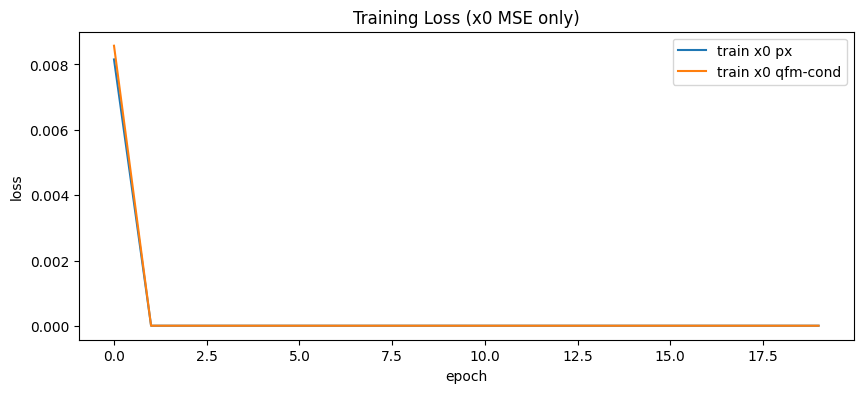

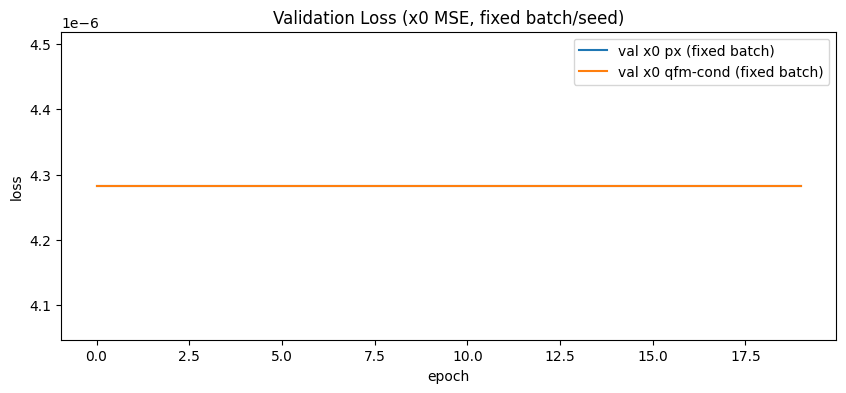

In [23]:
# Plot loss curves
plt.figure(figsize=(10, 4))
plt.plot(train_total_px, label='train total px')
plt.plot(train_total_q, label='train total qfm-cond')
plt.title('Training Loss (total, x0-pred + sparsity aux)')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(train_base_px, label='train x0 px')
plt.plot(train_base_q, label='train x0 qfm-cond')
plt.title('Training Loss (x0 MSE only)')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(val_base_px, label='val x0 px (fixed batch)')
plt.plot(val_base_q, label='val x0 qfm-cond (fixed batch)')
plt.title('Validation Loss (x0 MSE, fixed batch/seed)')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()



## 7. Sampling
- Baseline: unconditional sampling in pixel space.
- QFM-conditioned: sampling conditioned on **existing** QFM features (from val set).

For fully unconditional hybrid generation later, we’d need a separate model to generate QFM features.


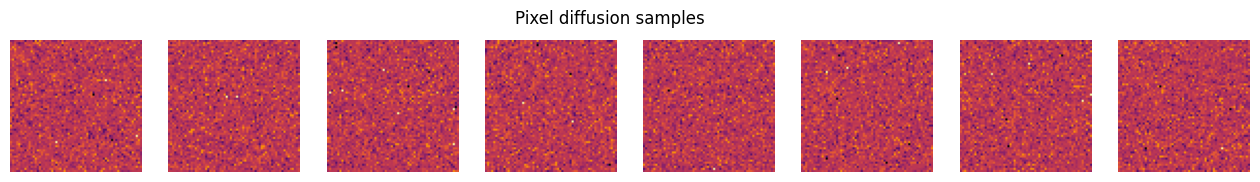

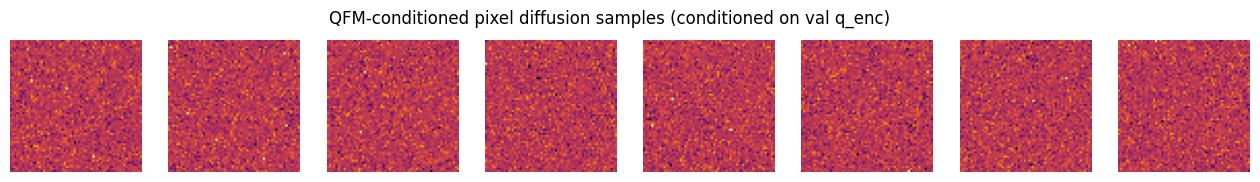

In [24]:
@torch.no_grad()
def p_sample(model, x, t, cond=None, clip_x0=True, x0_min=0.0, x0_max=1.0):
    betas_t = extract(betas, t, x.shape)
    sqrt_recip_alphas_t = extract(sqrt_recip_alphas, t, x.shape)
    sqrt_om = extract(sqrt_one_minus_alphas_cumprod, t, x.shape)

    # Model predicts x0 directly
    if cond is None:
        x0_pred = model(x, t)
    else:
        x0_pred = model(torch.cat([x, cond], dim=1), t)

    if clip_x0:
        x0_pred = torch.clamp(x0_pred, x0_min, x0_max)

    eps = predict_eps_from_x0(x, t, x0_pred)

    model_mean = sqrt_recip_alphas_t * (x - betas_t * eps / sqrt_om)
    if (t == 0).all():
        return model_mean

    noise = torch.randn_like(x)
    var = extract(posterior_variance, t, x.shape)
    return model_mean + torch.sqrt(var) * noise

@torch.no_grad()
def p_sample_loop(model, n, cond=None, clip_x0=True):
    x = torch.randn((n, 1, 64, 64), device=device)
    for i in reversed(range(T)):
        t = torch.full((n,), i, device=device, dtype=torch.long)
        x = p_sample(model, x, t, cond=cond, clip_x0=clip_x0)
    return x

# Unconditional pixel samples
samples_px = p_sample_loop(model_px, n=8, clip_x0=True)
show_imgs(samples_px, n=8, title='Pixel diffusion samples')

# Conditional samples using q_enc from validation set
q_cond = upsample_cond(val_q[:8].to(device))
samples_q = p_sample_loop(model_px_qfm, n=8, cond=q_cond, clip_x0=True)
show_imgs(samples_q, n=8, title='QFM-conditioned pixel diffusion samples (conditioned on val q_enc)')



## 8. One-step reconstruction + numeric comparison
We do a quick mid-timestep reconstruction test and compute MSE/SSIM/Wasserstein.
(FID-like on raw pixels is expensive at 64×64, so we skip it here.)


MSE:   Pixel=0.000004  QFM-Cond=0.000004
SSIM:  Pixel=0.9960  QFM-Cond=0.9960
Wass:  Pixel=0.000060  QFM-Cond=0.000060


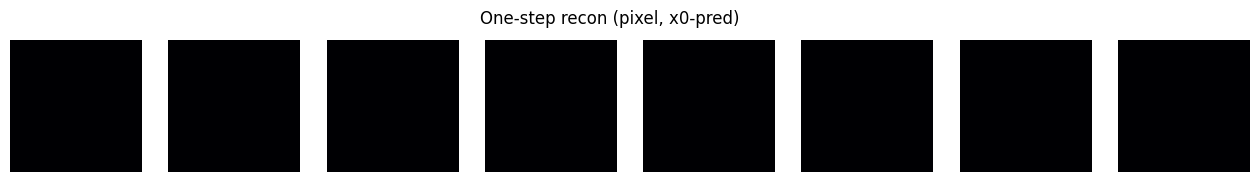

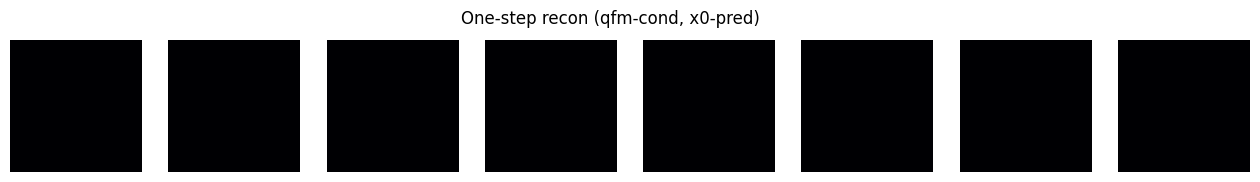

In [25]:
@torch.no_grad()
def one_step_recon_x0(model, x0, cond=None, t_val=None, gen=None):
    if t_val is None:
        t_val = torch.full((x0.shape[0],), T // 2, device=device, dtype=torch.long)
    if gen is None:
        gen = torch.Generator(device=device).manual_seed(seed + 2)

    eps = torch.randn(x0.shape, device=device, generator=gen)
    x_t = q_sample(x0, t_val, eps)

    if cond is None:
        x0_hat = model(x_t, t_val)
    else:
        x0_hat = model(torch.cat([x_t, cond], dim=1), t_val)

    return torch.clamp(x0_hat, 0.0, 1.0)

val_batch = val_batch_fixed
val_cond = val_cond_fixed

rec_px = one_step_recon_x0(model_px, val_batch)
rec_q = one_step_recon_x0(model_px_qfm, val_batch, cond=val_cond)

def npify(x):
    return x.detach().cpu().numpy().squeeze(1)

real = npify(val_batch)
r_px = npify(rec_px)
r_q = npify(rec_q)

real = np.clip(real, 0.0, 1.0)
r_px = np.clip(r_px, 0.0, 1.0)
r_q = np.clip(r_q, 0.0, 1.0)

def mean_ssim(a, b):
    return float(np.mean([ssim(a[i], b[i], data_range=1.0) for i in range(a.shape[0])]))

def mean_wass(a, b):
    from scipy.stats import wasserstein_distance
    return float(np.mean([wasserstein_distance(a[i].ravel(), b[i].ravel()) for i in range(a.shape[0])]))

mse_px = float(np.mean((r_px - real) ** 2))
mse_q = float(np.mean((r_q - real) ** 2))
ssim_px = mean_ssim(real, r_px)
ssim_q = mean_ssim(real, r_q)
wass_px = mean_wass(real, r_px)
wass_q = mean_wass(real, r_q)

print(f'MSE:   Pixel={mse_px:.6f}  QFM-Cond={mse_q:.6f}')
print(f'SSIM:  Pixel={ssim_px:.4f}  QFM-Cond={ssim_q:.4f}')
print(f'Wass:  Pixel={wass_px:.6f}  QFM-Cond={wass_q:.6f}')

show_imgs(rec_px, n=8, title='One-step recon (pixel, x0-pred)')
show_imgs(rec_q, n=8, title='One-step recon (qfm-cond, x0-pred)')



Active-pixel threshold (p99.5 of real intensity01): 1.801891e-03
Frac > thr: real 0.005001068115234375 px 0.0 qfm-cond 0.0
Total energy (mean±std): real (0.2453938126564026, 0.11622025072574615) px (0.0, 0.0) qfm-cond (0.0, 0.0)


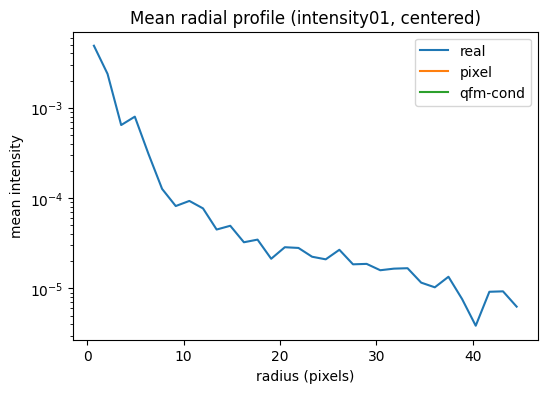

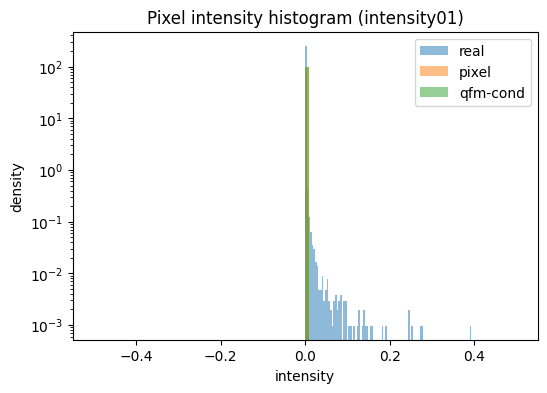

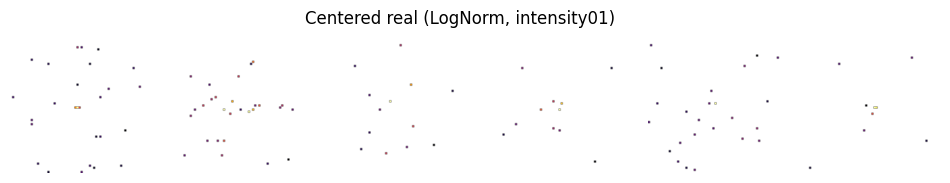

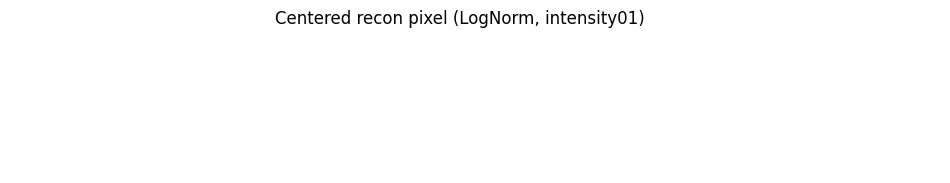

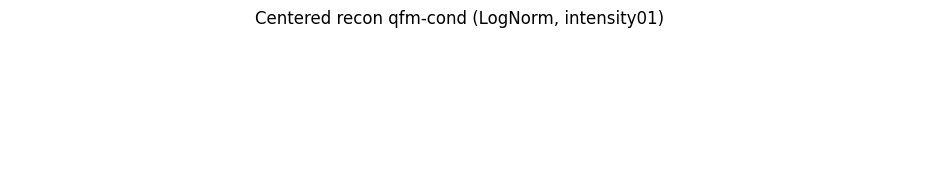

--- Sample diagnostics (centered, intensity01) ---
Frac > thr: px 0.0 qfm-cond 0.0
Total energy (mean±std): px (1.8966516108775977e-06, 4.213637083694266e-08) qfm-cond (1.8794191873894306e-06, 3.207926724257959e-08)


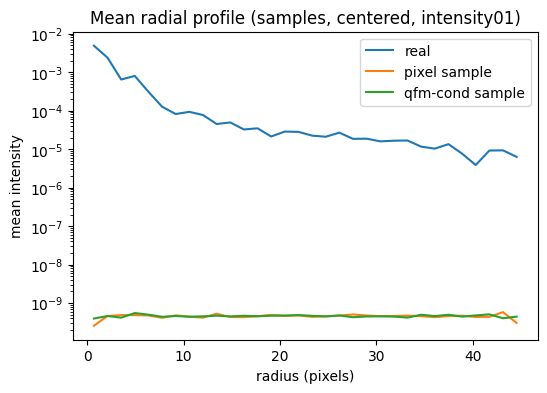

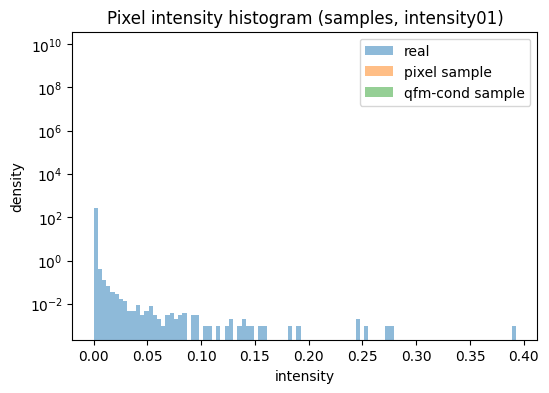

ValueError: vmin must be less or equal to vmax

<Figure size 1200x200 with 6 Axes>

ValueError: vmin must be less or equal to vmax

<Figure size 1200x200 with 6 Axes>

In [26]:
# Jet-aligned diagnostics (centroid alignment + sparsity-aware stats)
# Note: the training pixels are in [-1, 1]. For jet physics diagnostics we convert to an intensity-like space in [0, 1].
import matplotlib.colors as mcolors

@torch.no_grad()
def to_intensity01(x):
    # x: (N,1,H,W) in [-1,1] -> (N,1,H,W) in [0,1]
    return torch.clamp(x, 0.0, 1.0)

@torch.no_grad()
def center_by_energy_centroid(x01, nbins=None):
    # x01: (N,1,H,W) in [0,1]
    x01 = x01.clone()
    N, _, H, W = x01.shape

    w = x01
    w_sum = w.sum(dim=(2,3), keepdim=True) + 1e-8

    yy = torch.arange(H, device=x01.device).view(1, 1, H, 1).float()
    xx = torch.arange(W, device=x01.device).view(1, 1, 1, W).float()

    cy = (w * yy).sum(dim=(2,3), keepdim=True) / w_sum
    cx = (w * xx).sum(dim=(2,3), keepdim=True) / w_sum

    ty = (H // 2) - cy.squeeze(-1).squeeze(-1).squeeze(1)
    tx = (W // 2) - cx.squeeze(-1).squeeze(-1).squeeze(1)

    ty = torch.round(ty).to(torch.int64)
    tx = torch.round(tx).to(torch.int64)

    out = x01
    for i in range(N):
        out[i] = torch.roll(out[i], shifts=(int(ty[i].item()), int(tx[i].item())), dims=(1,2))
    return out

@torch.no_grad()
def radial_profile(batch01, nbins=32):
    # batch01: (N,1,H,W) in [0,1]
    N, _, H, W = batch01.shape
    cy, cx = H // 2, W // 2

    yy, xx = torch.meshgrid(torch.arange(H, device=batch01.device), torch.arange(W, device=batch01.device), indexing='ij')
    rr = torch.sqrt((yy - cy)**2 + (xx - cx)**2).float()

    rmax = rr.max().item()
    bins = torch.linspace(0.0, rmax + 1e-6, nbins + 1, device=batch01.device)

    prof = torch.zeros(nbins, device=batch01.device)

    rr_flat = rr.view(-1)
    x_flat = batch01.view(N, -1)

    for b in range(nbins):
        m = (rr_flat >= bins[b]) & (rr_flat < bins[b+1])
        if m.any():
            prof[b] = x_flat[:, m].mean()

    return prof.detach().cpu().numpy(), bins.detach().cpu().numpy()

@torch.no_grad()
def total_energy01(x01):
    return x01.sum(dim=(2,3)).detach().cpu().numpy()

# Convert to intensity space and center
val01 = to_intensity01(val_batch)
rec_px01 = to_intensity01(rec_px)
rec_q01 = to_intensity01(rec_q)

val_center = center_by_energy_centroid(val01)
rec_px_center = center_by_energy_centroid(rec_px01)
rec_q_center = center_by_energy_centroid(rec_q01)

real_pos = val_center.detach().cpu().numpy().ravel()
px_pos = rec_px_center.detach().cpu().numpy().ravel()
q_pos = rec_q_center.detach().cpu().numpy().ravel()

thr = float(np.percentile(real_pos, 99.5))

def frac_above(arr, thr):
    return float(np.mean(arr > thr))

E_real = total_energy01(val_center)
E_px = total_energy01(rec_px_center)
E_q = total_energy01(rec_q_center)

print(f'Active-pixel threshold (p99.5 of real intensity01): {thr:.6e}')
print('Frac > thr: real', frac_above(real_pos, thr), 'px', frac_above(px_pos, thr), 'qfm-cond', frac_above(q_pos, thr))
print('Total energy (mean±std): real', (float(E_real.mean()), float(E_real.std())),
      'px', (float(E_px.mean()), float(E_px.std())), 'qfm-cond', (float(E_q.mean()), float(E_q.std())))

# Radial profiles
prof_real, bins = radial_profile(val_center)
prof_px, _ = radial_profile(rec_px_center)
prof_q, _ = radial_profile(rec_q_center)

r = 0.5 * (bins[:-1] + bins[1:])
plt.figure(figsize=(6,4))
plt.plot(r, prof_real, label='real')
plt.plot(r, prof_px, label='pixel')
plt.plot(r, prof_q, label='qfm-cond')
plt.yscale('log')
plt.title('Mean radial profile (intensity01, centered)')
plt.xlabel('radius (pixels)')
plt.ylabel('mean intensity')
plt.legend()
plt.show()

# Histograms
plt.figure(figsize=(6,4))
plt.hist(real_pos, bins=100, alpha=0.5, label='real', density=True)
plt.hist(px_pos, bins=100, alpha=0.5, label='pixel', density=True)
plt.hist(q_pos, bins=100, alpha=0.5, label='qfm-cond', density=True)
plt.yscale('log')
plt.title('Pixel intensity histogram (intensity01)')
plt.xlabel('intensity')
plt.ylabel('density')
plt.legend()
plt.show()

# Visualize centered images with LogNorm

def show_imgs_lognorm(x01, n=6, title=''):
    x = x01[:n].detach().cpu().numpy()
    fig, axes = plt.subplots(1, n, figsize=(n*2, 2))
    for i in range(n):
        img = np.clip(x[i,0], 0.0, 1.0)
        # pick vmin from positive pixels if possible
        if (img > 0).any():
            vmin = float(np.min(img[img > 0]))
        else:
            vmin = 1e-6
        vmax = float(img.max()) if img.max() > 0 else 1.0
        axes[i].imshow(img, cmap='inferno', norm=mcolors.LogNorm(vmin=max(vmin, 1e-6), vmax=vmax))
        axes[i].axis('off')
    if title:
        fig.suptitle(title)
    plt.show()

show_imgs_lognorm(val_center, n=6, title='Centered real (LogNorm, intensity01)')
show_imgs_lognorm(rec_px_center, n=6, title='Centered recon pixel (LogNorm, intensity01)')
show_imgs_lognorm(rec_q_center, n=6, title='Centered recon qfm-cond (LogNorm, intensity01)')

# Also diagnose full reverse-process samples (if sampling cell was run)
if 'samples_px' in globals() and 'samples_q' in globals():
    samp_px01 = to_intensity01(samples_px)
    samp_q01 = to_intensity01(samples_q)

    samp_px_center = center_by_energy_centroid(samp_px01)
    samp_q_center = center_by_energy_centroid(samp_q01)

    samp_px_pos = samp_px_center.detach().cpu().numpy().ravel()
    samp_q_pos = samp_q_center.detach().cpu().numpy().ravel()

    E_s_px = total_energy01(samp_px_center)
    E_s_q = total_energy01(samp_q_center)

    print('--- Sample diagnostics (centered, intensity01) ---')
    print('Frac > thr: px', frac_above(samp_px_pos, thr), 'qfm-cond', frac_above(samp_q_pos, thr))
    print('Total energy (mean±std): px', (float(E_s_px.mean()), float(E_s_px.std())),
          'qfm-cond', (float(E_s_q.mean()), float(E_s_q.std())))

    prof_s_px, _ = radial_profile(samp_px_center)
    prof_s_q, _ = radial_profile(samp_q_center)

    plt.figure(figsize=(6,4))
    plt.plot(r, prof_real, label='real')
    plt.plot(r, prof_s_px, label='pixel sample')
    plt.plot(r, prof_s_q, label='qfm-cond sample')
    plt.yscale('log')
    plt.title('Mean radial profile (samples, centered, intensity01)')
    plt.xlabel('radius (pixels)')
    plt.ylabel('mean intensity')
    plt.legend()
    plt.show()

    plt.figure(figsize=(6,4))
    plt.hist(real_pos, bins=100, alpha=0.5, label='real', density=True)
    plt.hist(samp_px_pos, bins=100, alpha=0.5, label='pixel sample', density=True)
    plt.hist(samp_q_pos, bins=100, alpha=0.5, label='qfm-cond sample', density=True)
    plt.yscale('log')
    plt.title('Pixel intensity histogram (samples, intensity01)')
    plt.xlabel('intensity')
    plt.ylabel('density')
    plt.legend()
    plt.show()

    show_imgs_lognorm(samp_px_center, n=6, title='Centered pixel samples (LogNorm, intensity01)')
    show_imgs_lognorm(samp_q_center, n=6, title='Centered qfm-cond samples (LogNorm, intensity01)')


## Mean Centered Images

We average centered images to make global structure differences easier to see.



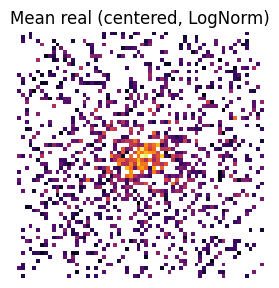

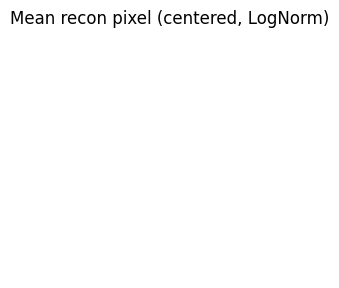

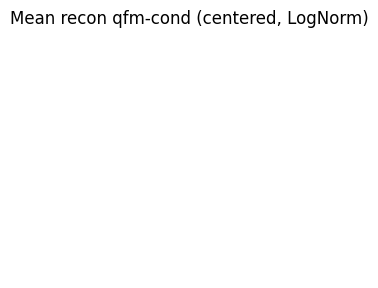

ValueError: vmin must be less or equal to vmax

<Figure size 320x320 with 1 Axes>

ValueError: vmin must be less or equal to vmax

<Figure size 320x320 with 1 Axes>

In [27]:
import matplotlib.colors as mcolors

@torch.no_grad()
def _to_intensity01(x):
    return torch.clamp(x, 0.0, 1.0)

@torch.no_grad()
def _center_by_energy_centroid(x01):
    # wraparound centering (torch.roll)
    x01 = x01.clone()
    N, _, H, W = x01.shape

    w = x01
    w_sum = w.sum(dim=(2,3), keepdim=True) + 1e-8

    yy = torch.arange(H, device=x01.device).view(1, 1, H, 1).float()
    xx = torch.arange(W, device=x01.device).view(1, 1, 1, W).float()

    cy = (w * yy).sum(dim=(2,3), keepdim=True) / w_sum
    cx = (w * xx).sum(dim=(2,3), keepdim=True) / w_sum

    ty = (H // 2) - cy.squeeze(-1).squeeze(-1).squeeze(1)
    tx = (W // 2) - cx.squeeze(-1).squeeze(-1).squeeze(1)

    ty = torch.round(ty).to(torch.int64)
    tx = torch.round(tx).to(torch.int64)

    out = x01
    for i in range(N):
        out[i] = torch.roll(out[i], shifts=(int(ty[i].item()), int(tx[i].item())), dims=(1,2))
    return out

def mean_centered_img(x):
    x01 = _to_intensity01(x)
    x01c = _center_by_energy_centroid(x01)
    return x01c.mean(dim=0)[0].detach().cpu().numpy()  # (H,W)

def show_mean(img, title):
    plt.figure(figsize=(3.2, 3.2))
    pos = img[img > 0]
    vmin = float(pos.min()) if pos.size else 1e-6
    vmax = float(img.max()) if img.max() > 0 else 1.0
    plt.imshow(img, cmap='inferno', norm=mcolors.LogNorm(vmin=max(vmin, 1e-6), vmax=vmax))
    plt.title(title)
    plt.axis('off')
    plt.show()

# Means from reconstructions (available if you ran the recon cell)
mean_real = mean_centered_img(val_batch)
mean_rec_px = mean_centered_img(rec_px)
mean_rec_q = mean_centered_img(rec_q)

show_mean(mean_real, 'Mean real (centered, LogNorm)')
show_mean(mean_rec_px, 'Mean recon pixel (centered, LogNorm)')
show_mean(mean_rec_q, 'Mean recon qfm-cond (centered, LogNorm)')

# Means from full samples (only if you ran sampling)
if 'samples_px' in globals() and 'samples_q' in globals():
    mean_s_px = mean_centered_img(samples_px)
    mean_s_q = mean_centered_img(samples_q)
    show_mean(mean_s_px, 'Mean pixel samples (centered, LogNorm)')
    show_mean(mean_s_q, 'Mean qfm-cond samples (centered, LogNorm)')
else:
    print('Sampling tensors not found (run the sampling cell first): samples_px, samples_q')




## Top-k Sparsified Comparison

To diagnose whether models capture the **sparse jet structure** but are swamped by background texture, we keep only the top fraction of pixels (per image) in intensity space and zero out the rest.
This is a diagnostic (not a physical postprocessing step we'd rely on downstream).


Global threshold from real at top 0.10%: thr=0.011188
[global-thr(top 0.10%)] Paired recon metrics (intensity01 sparsified):
  MSE:  Pixel=0.000004  QFM-Cond=0.000004
  SSIM: Pixel=0.9962  QFM-Cond=0.9962
  Wass: Pixel=0.000041  QFM-Cond=0.000041


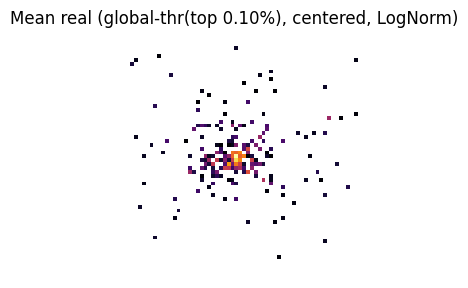

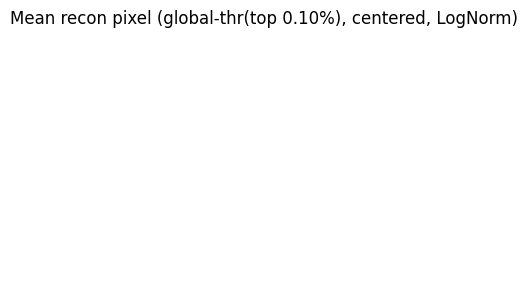

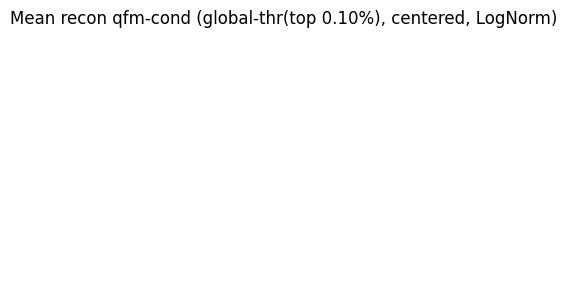

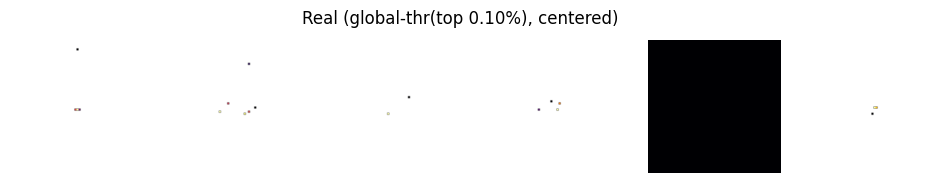

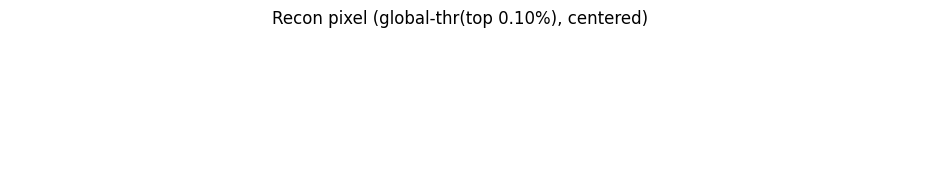

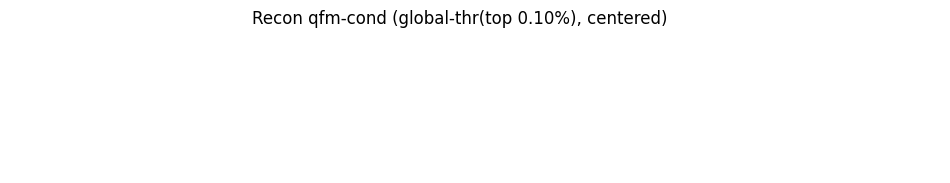

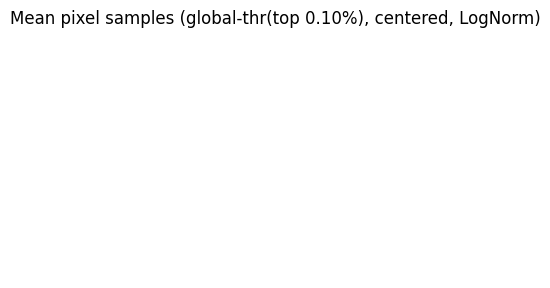

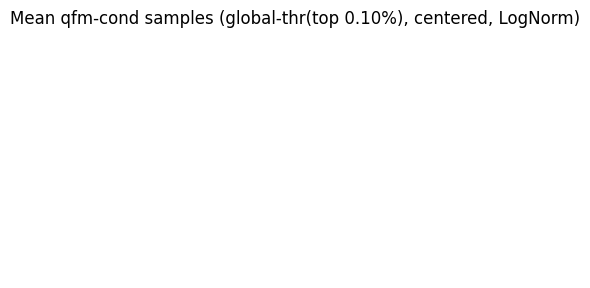

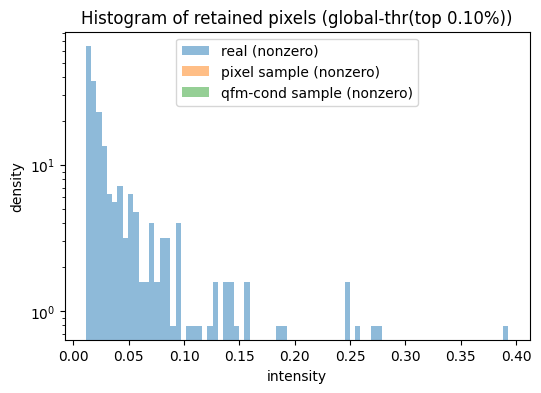

In [28]:
import matplotlib.colors as mcolors

# Sparsification diagnostics
# Method A: per-image top-k% (always keeps exactly k pixels per image; can keep pure noise if samples are dense)
keep_pct = 0.1

# Method B: global threshold derived from REAL pixels (keeps pixels above the (100-keep_pct)th percentile of real)
use_global_threshold = True

@torch.no_grad()
def to_intensity01(x):
    return torch.clamp(x, 0.0, 1.0)

@torch.no_grad()
def sparsify_topk_pct_per_image(x01, keep_pct):
    # x01: (N,1,H,W) in [0,1]
    N, _, H, W = x01.shape
    P = H * W
    k = max(1, int(round(P * keep_pct / 100.0)))

    flat = x01.view(N, -1)
    _, idx = torch.topk(flat, k, dim=1)
    mask = torch.zeros_like(flat)
    mask.scatter_(1, idx, 1.0)
    return (flat * mask).view_as(x01)

@torch.no_grad()
def sparsify_by_global_real_threshold(x01, thr):
    # x01: (N,1,H,W)
    return x01 * (x01 > thr).float()

@torch.no_grad()
def center_by_energy_centroid_roll(x01):
    # wraparound centering (torch.roll)
    x01 = x01.clone()
    N, _, H, W = x01.shape

    w = x01
    w_sum = w.sum(dim=(2,3), keepdim=True) + 1e-8

    yy = torch.arange(H, device=x01.device).view(1, 1, H, 1).float()
    xx = torch.arange(W, device=x01.device).view(1, 1, 1, W).float()

    cy = (w * yy).sum(dim=(2,3), keepdim=True) / w_sum
    cx = (w * xx).sum(dim=(2,3), keepdim=True) / w_sum

    ty = (H // 2) - cy.squeeze(-1).squeeze(-1).squeeze(1)
    tx = (W // 2) - cx.squeeze(-1).squeeze(-1).squeeze(1)

    ty = torch.round(ty).to(torch.int64)
    tx = torch.round(tx).to(torch.int64)

    out = x01
    for i in range(N):
        out[i] = torch.roll(out[i], shifts=(int(ty[i].item()), int(tx[i].item())), dims=(1,2))
    return out

@torch.no_grad()
def mean_centered_img(x01):
    x01c = center_by_energy_centroid_roll(x01)
    return x01c.mean(dim=0)[0].detach().cpu().numpy()

@torch.no_grad()
def show_mean(img, title):
    plt.figure(figsize=(3.2, 3.2))
    pos = img[img > 0]
    vmin = float(pos.min()) if pos.size else 1e-6
    vmax = float(img.max()) if img.max() > 0 else 1.0
    plt.imshow(img, cmap='inferno', norm=mcolors.LogNorm(vmin=max(vmin, 1e-6), vmax=vmax))
    plt.title(title)
    plt.axis('off')
    plt.show()

@torch.no_grad()
def show_imgs_lognorm(x01, n=6, title=''):
    x = x01[:n].detach().cpu().numpy()
    fig, axes = plt.subplots(1, n, figsize=(n*2, 2))
    for i in range(n):
        img = np.clip(x[i,0], 0.0, 1.0)
        pos = img[img > 0]
        vmin = float(pos.min()) if pos.size else 1e-6
        vmax = float(img.max()) if img.max() > 0 else 1.0
        axes[i].imshow(img, cmap='inferno', norm=mcolors.LogNorm(vmin=max(vmin, 1e-6), vmax=vmax))
        axes[i].axis('off')
    if title:
        fig.suptitle(title)
    plt.show()

@torch.no_grad()
def nonzero_flat(x01):
    arr = x01.detach().cpu().numpy().ravel()
    return arr[arr > 0]

# Build intensity01 tensors (paired for recon; unpaired for samples)
real01 = to_intensity01(val_batch)
px01 = to_intensity01(rec_px)
q01 = to_intensity01(rec_q)

# Threshold from REAL distribution (nonzero-aware)
real_flat = real01.detach().cpu().numpy().ravel()
thr = float(np.percentile(real_flat, 100.0 - keep_pct))
print(f'Global threshold from real at top {keep_pct:.2f}%: thr={thr:.6f}')

if use_global_threshold:
    real_k = sparsify_by_global_real_threshold(real01, thr)
    px_k = sparsify_by_global_real_threshold(px01, thr)
    q_k = sparsify_by_global_real_threshold(q01, thr)
    method = f'global-thr(top {keep_pct:.2f}%)'
else:
    real_k = sparsify_topk_pct_per_image(real01, keep_pct)
    px_k = sparsify_topk_pct_per_image(px01, keep_pct)
    q_k = sparsify_topk_pct_per_image(q01, keep_pct)
    method = f'per-image-topk({keep_pct:.2f}%)'

# Paired numeric comparison (reconstructions only)
real_np = real_k.detach().cpu().numpy().squeeze(1)
px_np = px_k.detach().cpu().numpy().squeeze(1)
q_np = q_k.detach().cpu().numpy().squeeze(1)

mse_px = float(np.mean((px_np - real_np) ** 2))
mse_q = float(np.mean((q_np - real_np) ** 2))

ssim_px = float(np.mean([ssim(real_np[i], px_np[i], data_range=1.0) for i in range(real_np.shape[0])]))
ssim_q = float(np.mean([ssim(real_np[i], q_np[i], data_range=1.0) for i in range(real_np.shape[0])]))

from scipy.stats import wasserstein_distance
wass_px = float(np.mean([wasserstein_distance(real_np[i].ravel(), px_np[i].ravel()) for i in range(real_np.shape[0])]))
wass_q = float(np.mean([wasserstein_distance(real_np[i].ravel(), q_np[i].ravel()) for i in range(real_np.shape[0])]))

print(f'[{method}] Paired recon metrics (intensity01 sparsified):')
print(f'  MSE:  Pixel={mse_px:.6f}  QFM-Cond={mse_q:.6f}')
print(f'  SSIM: Pixel={ssim_px:.4f}  QFM-Cond={ssim_q:.4f}')
print(f'  Wass: Pixel={wass_px:.6f}  QFM-Cond={wass_q:.6f}')

# Qualitative: mean centered images after sparsification
show_mean(mean_centered_img(real_k), f'Mean real ({method}, centered, LogNorm)')
show_mean(mean_centered_img(px_k), f'Mean recon pixel ({method}, centered, LogNorm)')
show_mean(mean_centered_img(q_k), f'Mean recon qfm-cond ({method}, centered, LogNorm)')

show_imgs_lognorm(center_by_energy_centroid_roll(real_k), n=6, title=f'Real ({method}, centered)')
show_imgs_lognorm(center_by_energy_centroid_roll(px_k), n=6, title=f'Recon pixel ({method}, centered)')
show_imgs_lognorm(center_by_energy_centroid_roll(q_k), n=6, title=f'Recon qfm-cond ({method}, centered)')

# Samples (unpaired): compare mean-centered and nonzero histograms after sparsification
if 'samples_px' in globals() and 'samples_q' in globals():
    s_px01 = to_intensity01(samples_px)
    s_q01 = to_intensity01(samples_q)

    if use_global_threshold:
        s_px_k = sparsify_by_global_real_threshold(s_px01, thr)
        s_q_k = sparsify_by_global_real_threshold(s_q01, thr)
    else:
        s_px_k = sparsify_topk_pct_per_image(s_px01, keep_pct)
        s_q_k = sparsify_topk_pct_per_image(s_q01, keep_pct)

    show_mean(mean_centered_img(s_px_k), f'Mean pixel samples ({method}, centered, LogNorm)')
    show_mean(mean_centered_img(s_q_k), f'Mean qfm-cond samples ({method}, centered, LogNorm)')

    # Histogram of NONZERO intensities (zeros dominate after sparsification)
    rz = nonzero_flat(real_k)
    pz = nonzero_flat(s_px_k)
    qz = nonzero_flat(s_q_k)

    plt.figure(figsize=(6,4))
    plt.hist(rz, bins=80, alpha=0.5, label='real (nonzero)', density=True)
    plt.hist(pz, bins=80, alpha=0.5, label='pixel sample (nonzero)', density=True)
    plt.hist(qz, bins=80, alpha=0.5, label='qfm-cond sample (nonzero)', density=True)
    plt.yscale('log')
    plt.title(f'Histogram of retained pixels ({method})')
    plt.xlabel('intensity')
    plt.ylabel('density')
    plt.legend()
    plt.show()
else:
    print('Sampling tensors not found (run the sampling cell first): samples_px, samples_q')
